In [69]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *
import itertools

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import skewnorm,skew
from scipy.stats import pearsonr
from scipy.linalg import toeplitz
from scipy.interpolate import CubicSpline
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style

import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import OLSInfluence,variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson,omni_normtest,\
                                        jarque_bera
from patsy import dmatrices,dmatrix

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import validation_curve
from sklearn.model_selection import GridSearchCV

# Multiclass
from sklearn.multiclass import OneVsOneClassifier,OneVsRestClassifier

# Base
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures,label_binarize

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris
from sklearn.datasets import load_sample_image

# calibration
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve

# metrics

from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import brier_score_loss

from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.metrics import confusion_matrix,precision_score,\
                            recall_score,f1_score,\
                            classification_report, accuracy_score,\
                            precision_recall_curve,\
                            roc_curve,auc, roc_auc_score,\
                            ConfusionMatrixDisplay,\
                            root_mean_squared_error    
                            
# neural_network
from sklearn.neural_network import MLPClassifier,\
                                   MLPRegressor,\
                                   BernoulliRBM

# tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

# linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Perceptron
#SVM
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from graphviz import Source

#ensemble
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier

#decomposition
from sklearn.decomposition import PCA

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.cluster import MiniBatchKMeans

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
#====================================
import tensorflow as tf
import h5py
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras import initializers
import visualkeras


from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
# layers
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Normalization,BatchNormalization
#CNN
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
#activations
from tensorflow.keras.activations import sigmoid
#utils
from tensorflow.keras.utils import to_categorical

#callbacks
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.callbacks import LambdaCallback
from tensorflow.keras.callbacks import TerminateOnNaN
from tensorflow.keras.callbacks import CSVLogger
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import Callback

#preprocessing 
from tensorflow.keras.preprocessing import image
import sys
from copy import deepcopy
import kagglehub


In [70]:
def reorder_and_clean_dmatrices(df__, formula__):
    """
    Reorder and clean DataFrame columns returned by dmatrices()
    according to the formula string.

    Steps:
    - Reorder columns to match formula sequence
    - Remove [T.True] suffix from categorical variables
    - Replace ':' with '*' in interaction terms
    """

    # Extract terms from formula
    terms = formula__.split('~')[1].split('+')
    terms = [t.strip() for t in terms]

    # Mapping categorical variables to dummy names
    mapping = {
        "MRD": "MRD[T.True]",
        "GR": "GR[T.True]",
        "BS": "BS[T.True]",
        "HW": "HW[T.True]",
        "AC": "AC[T.True]",
        "PAREA": "PAREA[T.True]",
        "FSS": "FSS[T.True]",
        "FSU": "FSU[T.True]"
    }

    ordered_cols = ["Intercept"]

    for term in terms:
        if "*" in term:  # interaction
            left, right = term.split("*")
            left, right = left.strip(), right.strip()
            if right in mapping:
                right = mapping[right]
            col_name = f"{left}:{right}"
            ordered_cols.append(col_name)
        else:  # main effect
            if term in mapping:
                ordered_cols.append(mapping[term])
            else:
                ordered_cols.append(term)

    # Reindex DataFrame
    df_reordered = df__[ordered_cols]

    # Clean column names
    df_reordered.columns = (
        df_reordered.columns
        .str.replace(r"\[T\.True\]", "", regex=True)  # remove [T.True]
        .str.replace(":", "*", regex=False)           # replace : with *
    )

    return df_reordered

In [71]:
path = os.path.join(os.getcwd(), 'DataSet', 'Housing.csv')
df = pd.read_csv(path)

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, columns=['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus'], drop_first=True)
print(df_encoded.columns.values)

df_encoded.columns = ['PR', 'AR', 'BD', 'BT', 'ST', 'PARK', 'MRD', 'GR', 'BS', 'HW', 'AC', 'PAREA', 'FSS', 'FSU']
df = df_encoded
print(df.shape,'\n',df.columns)

formulas_singal_line = 'PR ~ AR + BD + BT + ST + PARK + MRD + GR + BS + HW + AC + PAREA + FSS + FSU + AR*MRD + AR*GR + AR*BS + AR*HW + AR*AC + AR*PAREA + AR*FSS + AR*FSU + BD*MRD + BD*GR + BD*BS + BD*HW + BD*AC + BD*PAREA + BD*FSS + BD*FSU + BT*MRD + BT*GR + BT*BS + BT*HW + BT*AC + BT*PAREA + BT*FSS + BT*FSU + ST*MRD + ST*GR + ST*BS + ST*HW + ST*AC + ST*PAREA + ST*FSS + ST*FSU + PARK*MRD + PARK*GR + PARK*BS + PARK*HW + PARK*AC + PARK*PAREA + PARK*FSS + PARK*FSU'
formulas_two_line    = 'PR ~ AR + BD + BT + ST + PARK + MRD + GR + BS + HW + AC + PAREA + FSS + FSU'
print(f'len formulas_singal_line {len(formulas_singal_line)} & len formulas_two_line {len(formulas_two_line)}')

y_single_sol,X_single_sol = dmatrices(formula_like  = formulas_singal_line,data=df, return_type='dataframe')
X_single_sol = reorder_and_clean_dmatrices(df__ = X_single_sol, formula__ = formulas_singal_line)
y_two_line_sol,X_two_line_sol = dmatrices(formula_like  = formulas_two_line,data=df, return_type='dataframe')
X_two_line_sol = reorder_and_clean_dmatrices(df__ = X_two_line_sol, formula__ = formulas_two_line)
print(f'y_single_sol shape {y_single_sol.shape} X_single_sol shape {X_single_sol.shape}') 
print(f'y_two_line_sol shape {y_two_line_sol.shape} X_two_line_sol shape {X_two_line_sol.shape}')
print(f'X_single_sol : {type(X_single_sol)} X_two_line_sol:{type(X_two_line_sol)}')

standard_scaler = StandardScaler()
min_max_scaler  = MinMaxScaler(feature_range=(0,1))

X_scaled_std_scal_single_line = standard_scaler.fit_transform(X_single_sol)
X_scaled_min_max_scal_single_line = min_max_scaler.fit_transform(X_single_sol)

X_scaled_std_scal_two_line = standard_scaler.fit_transform(X_two_line_sol)
X_scaled_min_max_scal_two_line = min_max_scaler.fit_transform(X_two_line_sol)


['price' 'area' 'bedrooms' 'bathrooms' 'stories' 'parking' 'mainroad_yes'
 'guestroom_yes' 'basement_yes' 'hotwaterheating_yes'
 'airconditioning_yes' 'prefarea_yes' 'furnishingstatus_semi-furnished'
 'furnishingstatus_unfurnished']
(545, 14) 
 Index(['PR', 'AR', 'BD', 'BT', 'ST', 'PARK', 'MRD', 'GR', 'BS', 'HW', 'AC',
       'PAREA', 'FSS', 'FSU'],
      dtype='object')
len formulas_singal_line 441 & len formulas_two_line 75
y_single_sol shape (545, 1) X_single_sol shape (545, 54)
y_two_line_sol shape (545, 1) X_two_line_sol shape (545, 14)
X_single_sol : <class 'pandas.core.frame.DataFrame'> X_two_line_sol:<class 'pandas.core.frame.DataFrame'>


#### Qus: Is it possible to implement Ordinary Least Squares (OLS) based residual analyses and outlier detection methods in ridge regression using its hat matrix without modification ?

No, standard Ordinary Least Squares (OLS) based residual analyses and outlier detection methods are not directly applicable to ridge regression using its hat matrix without modification. This is because ridge regression introduces bias to the coefficients to handle multicollinearity, fundamentally changing the properties of the residuals and the hat matrix compared to OLS.

For OLS:

$H=X(X'X)^{-1}X'$

For Ridge:

$H_k=X(X'X+kI)^{-1}X'$

This $H_k$ is still a projection matrix, but not idempotent (i.e., $H_k^2\neq H_k$). Many OLS diagnostics that rely on **idempotency** (like exact variance of residuals) are approximate in ridge.

#### Using modified diagnostics designed:

Performing outlier and influential observation detection in ridge regression requires using modified diagnostics designed to account for the bias introduced by the penalty term ($k$). Standard OLS diagnostics are not suitable because they rely on assumptions of unbiasedness and specific variance properties that do not hold in ridge regression.

#### Modified Diagnostic Methods for Ridge Regression

1. Modified Cook's Distance $D_{k}$

Cook’s Distance is a diagnostic measure in regression analysis. It tells us how much the fitted regression model would change if a particular observation were removed. In other words: it combines residual size (how unusual the response is) and leverage (how unusual the predictor values are). 

Large Cook’s D values indicate influential points — observations that strongly affect the regression coefficients

Formula for Cook’s D (OLS):

For observation i:

$D_i=\frac{(\hat {\beta }_{(i)}-\hat {\beta })'X'X(\hat {\beta }_{(i)}-\hat {\beta })}{p\cdot MSE}$

Where:
- $\hat {\beta }$ = estimated coefficients using all data
- $\hat {\beta }_{(i)}$ = estimated coefficients with the i-th observation removed
- $X'X$ = information matrix from predictors
- $p$ = number of predictors (including intercept)
- $MSE$ = mean squared error of the regression

Modified Cook's distance for the regression coefficients is a generalization of the OLS formula:

$D_{k,i}=\frac{(\hat {\beta }_{(i)}-\hat {\beta })^T(X'X+kI)(\hat {\beta }_{(i)}-\hat {\beta })}{p\cdot \hat {\sigma }^2}$   --------- ($i$)

Eqn ($i$) can be expressed in terms of the modified leverage $h_{k,ii}$, the $i^th$ diagonal element of $H_{k}$ and the residual $e_{i}$

$D_{k,i}=\frac{e_{i}^{2}h_{k,ii}}{p\^{\sigma }^{2}(1-h_{k,ii})^{2}}$

Cutoff Values Unlike OLS, there is no single fixed thumb rule for the cutoff value due to the bias introduced by $k$.

**Remember: thresholds like $D_i>1$ are heuristics in ridge — use them comparatively, not as strict cutoffs.**

#### Modified DFFITS in Ridge Regression:

DFFITS (Difference in Fits) for ridge regression measures how much an observation's own fitted value changes when it is removed from the model.

The formula is a modification of the OLS DFFITS:

$\mathrm{DFFITS_{\mathnormal{k,i}}}=\frac{\hat {y}_i-\hat {y}_{(i)}}{\hat {\sigma }_{(i)}\sqrt{h_{k,ii}}}$

Where:
- $\hat {y}_i$: the fitted value for observation i in the full ridge regression model.
- $\hat {y}_{(i)}$: the fitted value for observation i when that observation is deleted from the model.
- $\hat {\sigma }_{(i)}$: the error standard deviation estimated without the i-th observation.
- $h_{k,ii}$: the leverage of observation i from the ridge hat matrix H$_k.

Cutoff Values
A common guideline is to flag observations where the absolute value of

$\mathrm{DFFITS_{\mathnormal{k,i}}}>2\times \sqrt{\frac{p+1}{n}}$

This threshold should be treated as a flexible guideline rather than a strict rule, especially in the ridge regression context.

#### Modified DFBETAs
DFBETAs measure the change in each specific regression coefficient j when the i-th observation is deleted.

$\mathrm{DFBETAS_{\mathnormal{k,i,j}}}=\frac{\hat {\beta }_j-\hat {\beta }_{j(i)}}{\hat {\sigma }_{(i)}\sqrt{(X'X+kI)_{jj}^{-1}}}$

Where:

- $\hat {\beta }_j$: coefficient $j$ estimated with all observations.
- $\hat {\beta }_{j(i)}$: coefficient $j$ estimated with the i-th observation removed.
- $\hat {\sigma }_{(i)}$: error standard deviation estimated without the $i-th$ observation.
- $(X'X+kI)_{jj}^{-1}$: the $j-th$ diagonal element of the ridge covariance matrix.

Cutoff Values:

Observations are typically considered influential if the absolute value of

$\mathrm{DFBETAS_{\mathnormal{k,i,j}}}>\frac{2}{\sqrt{n}}\quad \mathrm{or}\quad \frac{2}{\sqrt{\mathrm{effective\  degrees\  of\  freedom}}}$

- This threshold is a rule of thumb, not a strict cutoff.
- The determination depends heavily on the context of the dataset and the chosen ridge penalty parameter $k$.
- Larger sample sizes (higher $n$) make the cutoff smaller, meaning stricter detection of influential points.
- Using effective degrees of freedom (trace of the ridge hat matrix) instead of raw $n$ can be more appropriate in ridge regression, since shrinkage reduces model complexity.





In [72]:
#ridge_penalty_param = [10.0,100.0,174.614, 2090,2231.6829,2140,2220, 2230,2240]
ridge_penalty_param = [174.614, 2090,2231.6829,2140,2220, 2230,2240]
ridge_penalty_param.sort()
ridge_penalty_param

[174.614, 2090, 2140, 2220, 2230, 2231.6829, 2240]

In [73]:
def ridge_diagnostics(X_regressor, y_dependent, k_values):
    """
    Compute ridge hat matrix, residuals, and Cook's Distance analogue for each k.

    Parameters
    ----------
    results : dict
        Dictionary keyed by k, with values containing:
        - Hk : ridge hat matrix
        - residuals : residual vector
        - cooksD : array of Cook's Distance analogue for each observation
    """
    X__ = np.asarray(X_regressor)
    y__ = np.asarray(y_dependent).flatten()  # Ensure y__ is a 1D array
    n, p = X_regressor.shape
    XtX = X__.T @ X__
    Xty = X__.T @ y__
    I = np.eye(p)
    results = {}

    for k in k_values:
        # Ridge coefficients
        beta_ridge = np.linalg.inv(XtX + (k * I)) @ Xty        
        XtX_inv_k = np.linalg.pinv(XtX + (k * I))
        L = XtX_inv_k @ X__.T
        # Hat matrix
        Hk = X__ @ L + X__ @ XtX_inv_k @ X__.T
        
        # Predictions and residuals
        y_hat = X__ @ beta_ridge
        residuals = y__ - y_hat.flatten()  # Ensure y_hat is also 1D
        
        # Effective degrees of freedom
        df_ridge = np.trace(Hk)
        
        # Variance estimate
        sigma2_ridge = (residuals @ residuals) / (n - df_ridge)
        
        # Cook's Distance analogue
        h_diag = np.diag(Hk)
        cooksD = (residuals**2 * h_diag) / (p * sigma2_ridge * (1 - h_diag)**2)
        
        results[k] = {
            "Hk": Hk,
            "residuals": residuals,
            "cooksD": cooksD
        }
    return results




In [74]:
InfuanceData = ridge_diagnostics(X_regressor = X_scaled_std_scal_single_line, 
                  y_dependent = y_single_sol, 
                  k_values = ridge_penalty_param, 
                 )

In [75]:
def ridge_influence_diagnostics(X_regressor, y_dependent, k_values):
    """
    Compute ridge hat matrix, residuals, Cook's D, DFBETAs, and DFFITS for each k.

    Parameters
    ----------
    X_regressor : ndarray (n_samples, n_features)
        Design matrix of predictors. Shape (545, 54).
    y_dependent : pandas.DataFrame (n_samples, 1)
        Response vector. Shape (545, 1).
    k_values : list of floats
        List of ridge penalty values (lambda/k).

    Returns
    -------
    results : dict
        Dictionary keyed by k, with values containing:
        - Hk : ridge hat matrix
        - residuals : residual vector
        - cooksD : Cook's Distance analogue
        - dfbetas : array (n_samples, n_features) of DFBETAs
        - dffits : array of DFFITS values
    """
    # Convert y_dependent to numpy 1D array
    if isinstance(y_dependent, pd.DataFrame):
        y_dependent = y_dependent.values.ravel()
    elif isinstance(y_dependent, np.ndarray) and y_dependent.ndim == 2:
        y_dependent = y_dependent.ravel()

    n, p = X_regressor.shape
    XtX = X_regressor.T @ X_regressor
    Xty = X_regressor.T @ y_dependent

    results = {}

    for k in k_values:
        k = float(k)   # force float key
        # Ridge coefficients
        beta_ridge = np.linalg.inv(XtX + k * np.eye(p)) @ Xty
        
        # Hat matrix
        Hk = X_regressor @ np.linalg.inv(XtX + k * np.eye(p)) @ X_regressor.T
        
        # Predictions and residuals
        y_hat = X_regressor @ beta_ridge
        residuals = y_dependent - y_hat
        
        # Effective degrees of freedom
        df_ridge = np.trace(Hk)
        
        # Variance estimate
        sigma2_ridge = (residuals @ residuals) / (n - df_ridge)
        sigma_ridge = np.sqrt(sigma2_ridge)
        
        # Diagonal of hat matrix
        h_diag = np.diag(Hk)
        
        # Cook's Distance analogue
        cooksD = (residuals**2 * h_diag) / (p * sigma2_ridge * (1 - h_diag)**2)
        
        # DFFITS
        dffits = (residuals / (sigma_ridge * np.sqrt(1 - h_diag))) * np.sqrt(h_diag / (1 - h_diag))
        
        # DFBETAs (approximate)
        cov_ridge = np.linalg.inv(XtX + k * np.eye(p))
        dfbetas = np.zeros((n, p))
        for i in range(n):
            for j in range(p):
                dfbetas[i, j] = (residuals[i] / (sigma_ridge * np.sqrt(1 - h_diag[i]))) * \
                                (X_regressor[i, j] / np.sqrt(cov_ridge[j, j]))
        
        results[k] = {
            "Hk": Hk,
            "residuals": residuals,
            "cooksD": cooksD,
            "dffits": dffits,
            "dfbetas": dfbetas
        }

    return results

In [76]:
def ridge_hat_matrix(X_regressor: np.ndarray, k: float) -> np.ndarray:
    """
    Compute the ridge regression hat matrix H_k = X (X'X + kI)^(-1) X'.
    Returns
    -------
    H_k : np.ndarray
        Hat matrix of shape (n, n).
    """
    # Ensure X is numpy array
    X = np.asarray(X_regressor)
    
    # Dimensions
    n, p = X.shape
    
    # Compute (X'X + kI)^(-1)
    XtX = X.T @ X
    ridge_term = XtX + k * np.eye(p)
    ridge_inv = np.linalg.inv(ridge_term)
    
    # Hat matrix
    H_k = X @ ridge_inv @ X.T
    return H_k

In [77]:
def ridge_diagnostics_to_dataframes(diagnostics):
    """
    Convert ridge diagnostics dictionary into pandas DataFrames
    for Cook's D, DFFITS, and DFBETAs.

    Parameters
    ----------
    diagnostics : dict
        Output from ridge_influence_diagnostics(), keyed by k values.

    Returns
    -------
    cooksD_df : pd.DataFrame
        Cook's Distance values, rows = observations, cols = k values.
    dffits_df : pd.DataFrame
        DFFITS values, rows = observations, cols = k values.
    dfbetas_dict : dict of pd.DataFrame
        DFBETAs values, one DataFrame per k value
        (rows = observations, cols = predictors).
    """
    cooksD_df = pd.DataFrame()
    dffits_df = pd.DataFrame()
    dfbetas_dict = {}

    for k, metrics in diagnostics.items():
        # Cook's D
        cooksD_df[k] = metrics["cooksD"]

        # DFFITS
        dffits_df[k] = metrics["dffits"]

        # DFBETAs (matrix: n_samples x n_features)
        dfbetas_dict[k] = pd.DataFrame(metrics["dfbetas"],
                                       columns=[f"beta_{j}" for j in range(metrics["dfbetas"].shape[1])])

    return cooksD_df, dffits_df, dfbetas_dict

In [78]:
diagnostics = ridge_influence_diagnostics(X_regressor = X_scaled_std_scal_single_line, 
                  y_dependent = y_single_sol, 
                  k_values = ridge_penalty_param)
print(diagnostics.keys())

# Replace 1.0 with a valid key from ridge_penalty_param, e.g., 174.614
#valid_k = ridge_penalty_param[0]  # Use the first value in ridge_penalty_param as an example
cooksD_df, dffits_df, dfbetas_dict = ridge_diagnostics_to_dataframes(diagnostics)


dict_keys([174.614, 2090.0, 2140.0, 2220.0, 2230.0, 2231.6829, 2240.0])


In [79]:
# Remove decimals and convert to string list
string_list = [f'{(int(v))}' for v in list(cooksD_df.columns.values)]
cooksD_df.columns = string_list

#### Cutoff value of CooksD

$D_i > 1$ Not strict cutoff.

In [80]:
Di = 1
for col in cooksD_df.columns:
    print(f"\nResults for column: {col}")    
    # Filter rows where values > 1
    filtered = cooksD_df[cooksD_df[col] > Di]    
    if filtered.empty:
        print("Not found")
    else:
        print("CooksIndices:", filtered.index.tolist())


Results for column: 174
Not found

Results for column: 2090
Not found

Results for column: 2140
Not found

Results for column: 2220
Not found

Results for column: 2230
Not found

Results for column: 2231
Not found

Results for column: 2240
Not found


In [81]:
n,p = X_scaled_std_scal_single_line.shape
dffits_cutoff = 2*np.sqrt((p+1)/n)

for col in dffits_df.columns:
    print(f"\nResults for column: {col}")    
    # Filter rows where values > 1
    filtered = dffits_df[dffits_df[col] > dffits_cutoff]    
    if filtered.empty:
        print("Not found")
    else:
        print("DFFITS  Indices:", filtered.index.tolist())


Results for column: 174.614
DFFITS  Indices: [7, 11, 66]

Results for column: 2090.0
Not found

Results for column: 2140.0
Not found

Results for column: 2220.0
Not found

Results for column: 2230.0
Not found

Results for column: 2231.6829
Not found

Results for column: 2240.0
Not found


In [82]:
n,p = X_scaled_std_scal_single_line.shape
DFBETAs_cutoff = 2/np.sqrt(n)
for k, df__ in dfbetas_dict.items():
    for col in df__.columns:
        print(f"\nResults for column: {col}")    
        # Filter rows where values > 1
        filtered = df__[df__[col] > DFBETAs_cutoff]    
        if filtered.empty:
            print("Not found")
        else:
            print("DFBETAs cutoff Indices:", filtered.index.tolist())


Results for column: beta_0
Not found

Results for column: beta_1
DFBETAs cutoff Indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 19, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 49, 50, 51, 52, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 71, 73, 76, 77, 78, 79, 80, 82, 83, 85, 86, 88, 89, 91, 93, 94, 96, 97, 98, 99, 100, 101, 102, 103, 104, 106, 107, 109, 110, 111, 113, 114, 115, 116, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 131, 132, 134, 135, 136, 139, 140, 141, 142, 146, 147, 148, 149, 152, 155, 156, 158, 160, 161, 162, 163, 164, 165, 166, 169, 170, 171, 172, 173, 175, 176, 177, 178, 181, 183, 186, 187, 188, 190, 191, 192, 194, 196, 198, 203, 205, 206, 209, 211, 216, 217, 219, 220, 222, 223, 224, 225, 226, 227, 229, 230, 235, 244, 245, 247, 252, 255, 257, 259, 274, 277, 279, 280, 284, 285, 287, 289, 298, 299, 304, 310, 311, 315, 316, 323, 327, 331, 332, 336, 340, 342, 35

In [83]:
cooksD_df.columns

Index(['174', '2090', '2140', '2220', '2230', '2231', '2240'], dtype='object')

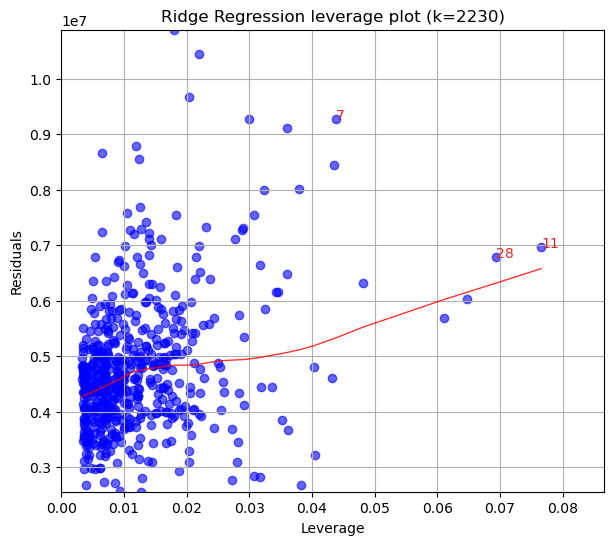

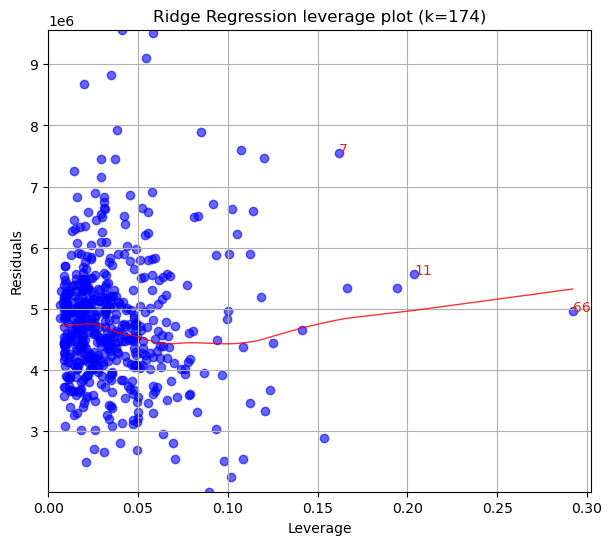

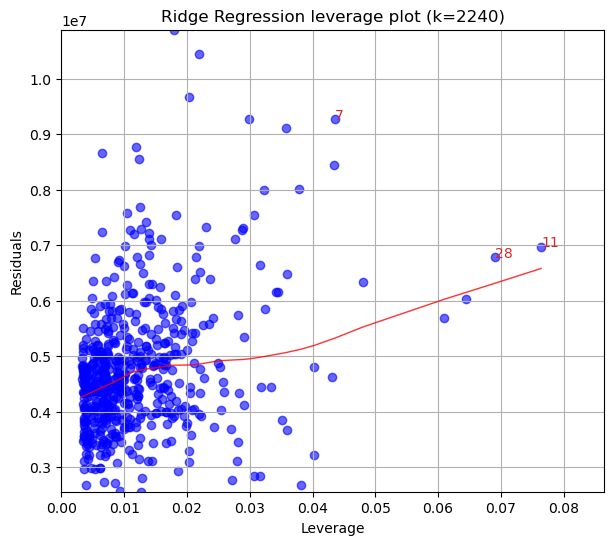

In [84]:
def __cooks_dist_line(factor,nparams_,leverage_):
    """
    Helper function for plotting Cook's distance curves
    """
    p = nparams_
    formula = lambda x: np.sqrt((factor * p * (1 - x)) / x)
    x__ = np.linspace(0.001, max(leverage_), 50)
    y__ = formula(x__)
    return x__, y__
    
def residuals_vs_leverage_plot(X_regressor: np.ndarray, 
                               y_dependent: pd.Series, 
                               k: float, 
                               cooks_distance,
                               cooks_threshold="baseR",
                               high_leverage_threshold=False,
                               model_name: str = "Ridge Regression leverage plot"):
    """
    Plot Residuals vs. Leverage for a single ridge penalty value (k).
    """
    X = np.asarray(X_regressor)
    y = np.asarray(y_dependent).reshape(-1, 1)
    n, p = X.shape
    nparams = p
    nresids = y_dependent.shape[0]
    #print(nparams,nresids)
    # Hat matrix for ridge
    H_k = ridge_hat_matrix(X_regressor = X_regressor, k = k)

    # Fitted values and residuals
    y_hat = H_k @ y
    residuals = (y - y_hat).flatten()

    # Leverage = diagonal of hat matrix
    leverage = np.diag(H_k)

    # Plot residuals vs leverage
    plt.figure(figsize=(7, 6))
    plt.scatter(leverage, residuals, alpha=0.6, color="blue")
    sns.regplot(
            x=leverage,
            y=residuals,
            scatter=False,
            ci=False,
            lowess=True,
            line_kws={"color": "red", "lw": 1, "alpha": 0.8},
        )
    if f'{k}' not in cooks_distance.columns:
        raise ValueError(f"Missing required columns: {k}")

    # annotations
    leverage_top_3 = np.flip(np.argsort(cooks_distance[f'{k}']), 0)[:3]
    for i in leverage_top_3:
        plt.annotate(i, xy=(leverage[i], residuals[i]), color="C3")
    
    factors = []
    if cooks_threshold == "baseR" or cooks_threshold is None:
        factors = [1, 0.5]
    elif cooks_threshold == "convention":
        factors = [4 / nresids]
    elif cooks_threshold == "dof":
        factors = [4 / (nresids - nparams)]
    else:
        raise ValueError(
            "threshold_method must be one of the following: 'convention', 'dof', or 'baseR' (default)"
        )
    '''    
    for i, factor in enumerate(factors):
        label = "Cook's distance" if i == 0 else None
        xtemp, ytemp = __cooks_dist_line(factor    = factors,
                                         nparams_  = nparams,
                                         leverage_ = leverage)
        plt.plot(xtemp, ytemp, label=label, lw=1.25, ls="--", color="red")
        plt.plot(xtemp, np.negative(ytemp), lw=1.25, ls="--", color="red")

    '''    
    plt.axhline(0, ls="dotted", color="black", lw=1.25)
    plt.xlim(0, max(leverage) + 0.01)
    plt.ylim(min(residuals) - 0.1, max(residuals) + 0.1)
    plt.xlabel("Leverage")
    plt.ylabel("Residuals")
    plt.title(f"{model_name} (k={k})")
    plt.grid(True)
    plt.show()

k_list_ = ['174', '2090', '2140', '2220', '2230', '2231', '2240']# columns name cooks D
residuals_vs_leverage_plot(X_regressor = X_scaled_std_scal_single_line, 
                               y_dependent = y_single_sol, 
                               k = 2230,
                               cooks_distance = cooksD_df
                               )

residuals_vs_leverage_plot(X_regressor = X_scaled_std_scal_single_line, 
                               y_dependent = y_single_sol, 
                               k = 174,
                               cooks_distance = cooksD_df
                               )

residuals_vs_leverage_plot(X_regressor = X_scaled_std_scal_single_line, 
                               y_dependent = y_single_sol, 
                               k = 2240,
                               cooks_distance = cooksD_df
                               )